# Generalization Experiments

Generalization Gap: difference between training and test accuracy 

In [1]:
# Cell 1: Imports and Data Loading
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import json
import numpy as np

# Load the datasets
best_per_dataset = pd.read_csv('../processed_results/best_per_dataset.csv')
best_avg = pd.read_csv('../processed_results/best_avg.csv')
results_hp = pd.read_csv('../processed_results/results_with_hyperparameters.csv')

# Set aesthetic style
sns.set_theme(style="whitegrid")
%matplotlib inline

/var/folders/f2/g658svqn1s7ff_f07dxlbl480000gn/T/ipykernel_36511/3067802320.py:12: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  results_hp = pd.read_csv('../processed_results/results_with_hyperparameters.csv')


In [2]:
# Cell 1: Imports and Data Loading
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

# 1. Define the exclusion set
excluded_datasets = {'avila', 'bean', 'eye-state', 'fault', 'page', 'room', 'segment'}

# 2. Load the datasets
best_per_dataset_raw = pd.read_csv('../processed_results/best_per_dataset.csv')
best_avg_raw = pd.read_csv('../processed_results/best_avg.csv')
results_hp_raw = pd.read_csv('../processed_results/results_with_hyperparameters.csv')

# 3. Apply Global Filtering
# We filter out any dataset in the excluded list
best_per_dataset = best_per_dataset_raw[~best_per_dataset_raw['dataset'].isin(excluded_datasets)].copy()
results_hp = results_hp_raw[~results_hp_raw['dataset'].isin(excluded_datasets)].copy()

# Note: best_avg usually does not have a 'dataset' column as it is already 
# averaged across all datasets. If you want the 'best_avg' to reflect ONLY 
# your included datasets, you should RE-CALCULATE it from the filtered 'best_per_dataset'
metrics = ["train_acc", "val_acc", "test_acc", "elapsed_time", "generalization_gap"]
existing_metrics = [m for m in metrics if m in best_per_dataset.columns]

best_avg = (
    best_per_dataset.groupby("model")[existing_metrics]
    .mean(numeric_only=True)
    .round(3)
    .reset_index()
)

# Set aesthetic style
sns.set_theme(style="whitegrid")
%matplotlib inline

print(f"Global filter applied.")
print(f"Datasets included: {results_hp['dataset'].unique()}")

Global filter applied.
Datasets included: ['skin' 'wilt' 'magic' 'rice' 'bank' 'occupancy' 'bidding' 'htru' 'raisin']


/var/folders/f2/g658svqn1s7ff_f07dxlbl480000gn/T/ipykernel_36511/3699391794.py:14: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  results_hp_raw = pd.read_csv('../processed_results/results_with_hyperparameters.csv')


### After the reset of the process results (only run this portion)

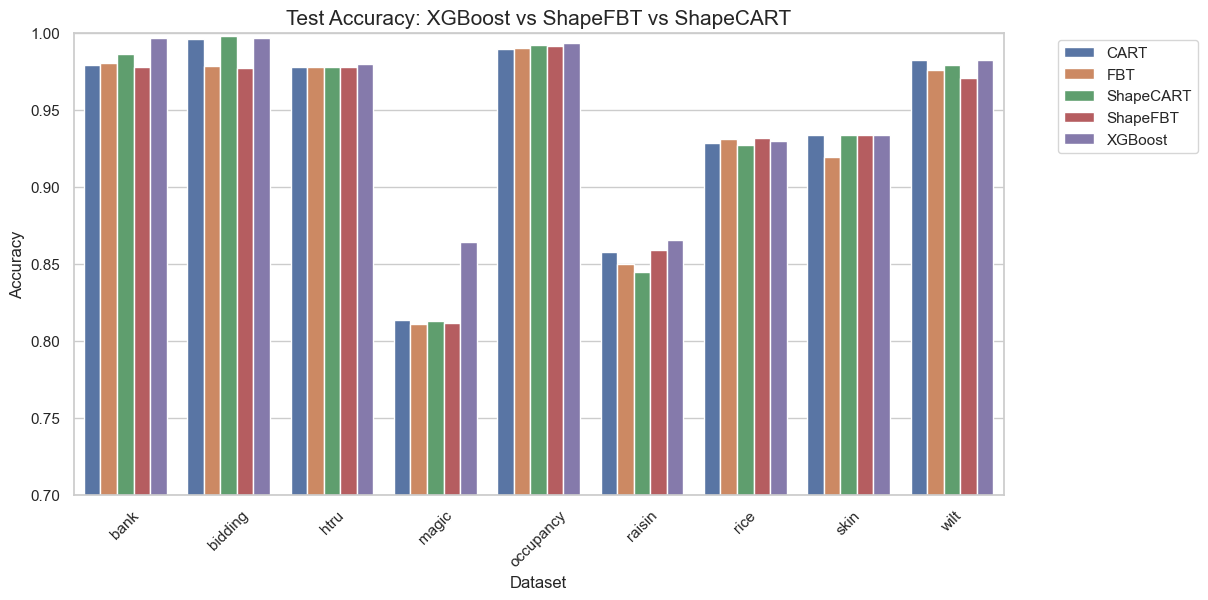

In [3]:
plt.figure(figsize=(12, 6))
sns.barplot(data=best_per_dataset, x='dataset', y='test_acc', hue='model')
plt.title('Test Accuracy: XGBoost vs ShapeFBT vs ShapeCART', fontsize=15)
plt.ylabel('Accuracy')
plt.xlabel('Dataset')
plt.ylim(0.7, 1.0) # Adjusted to zoom in on the differences
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

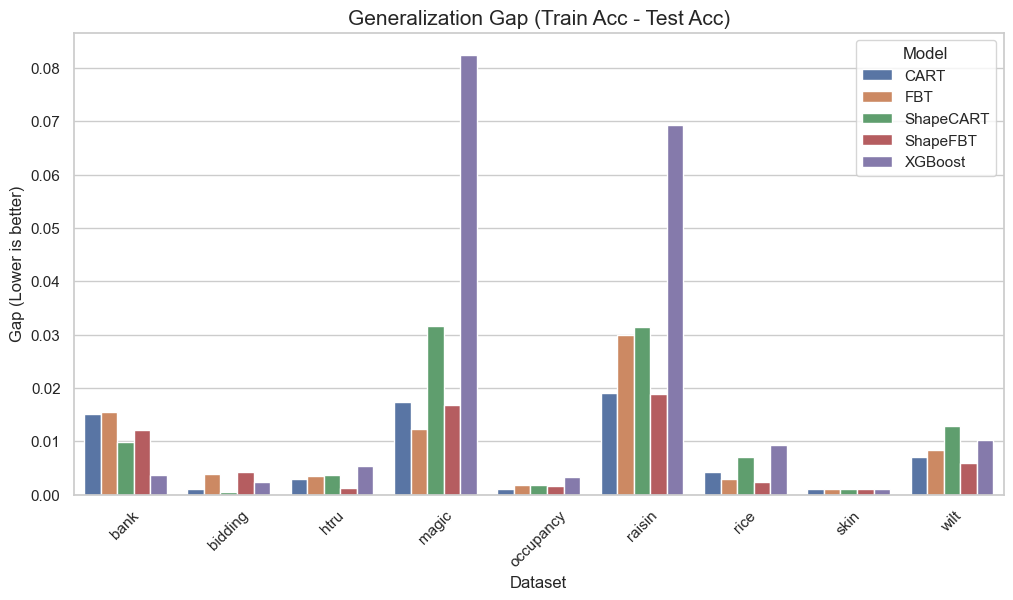

In [4]:
# Cell 3: Generalization Gap Analysis
# (Lower is better - indicates less overfitting)
plt.figure(figsize=(12, 6))
sns.barplot(data=best_per_dataset, x='dataset', y='generalization_gap', hue='model')
plt.title('Generalization Gap (Train Acc - Test Acc)', fontsize=15)
plt.ylabel('Gap (Lower is better)')
plt.xlabel('Dataset')
plt.legend(title='Model')
plt.xticks(rotation=45)
plt.show()

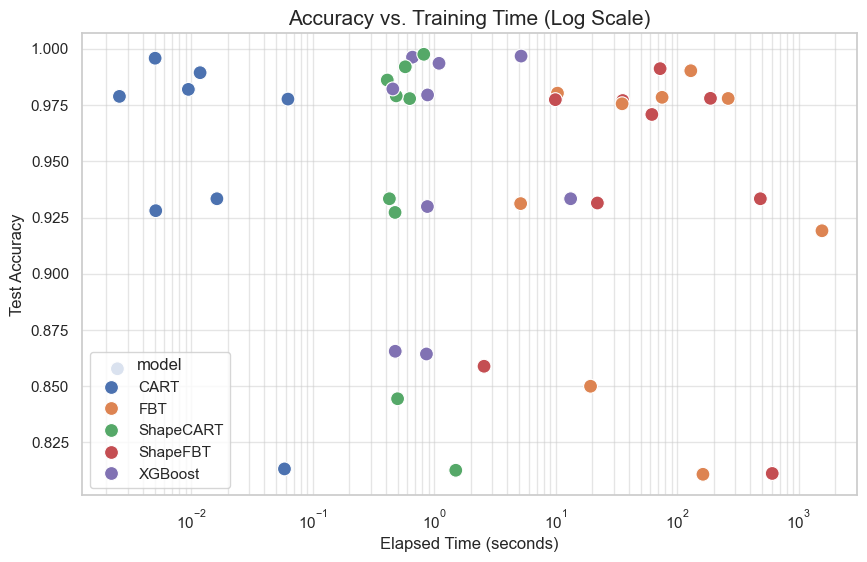

In [5]:
# Cell 4: Performance vs. Training Time (Log Scale)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=best_per_dataset, x='elapsed_time', y='test_acc', hue='model', s=100)
plt.xscale('log')
plt.title('Accuracy vs. Training Time (Log Scale)', fontsize=15)
plt.xlabel('Elapsed Time (seconds)')
plt.ylabel('Test Accuracy')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

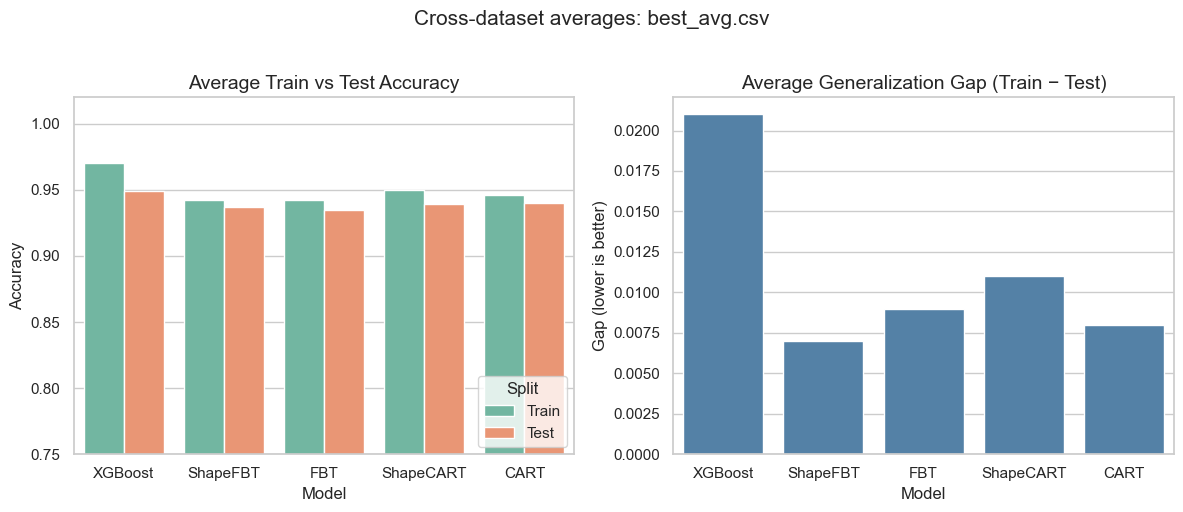

In [6]:
# Cell 5: Dataset-averaged metrics (best_avg.csv)
model_order = ['XGBoost', 'ShapeFBT', 'FBT', 'ShapeCART', 'CART']
plot_models = best_avg.copy()
plot_models['model'] = pd.Categorical(plot_models['model'], categories=model_order, ordered=True)
plot_models = plot_models.sort_values('model')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

acc_long = plot_models.melt(
    id_vars=['model'],
    value_vars=['train_acc', 'test_acc'],
    var_name='split',
    value_name='accuracy',
)
acc_long['split'] = acc_long['split'].map({'train_acc': 'Train', 'test_acc': 'Test'})

sns.barplot(data=acc_long, x='model', y='accuracy', hue='split', ax=axes[0], palette='Set2')
axes[0].set_title('Average Train vs Test Accuracy', fontsize=14)
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Model')
axes[0].set_ylim(0.75, 1.02)
axes[0].legend(title='Split', loc='lower right')

sns.barplot(data=plot_models, x='model', y='generalization_gap', ax=axes[1], color='steelblue')
axes[1].set_title('Average Generalization Gap (Train − Test)', fontsize=14)
axes[1].set_ylabel('Gap (lower is better)')
axes[1].set_xlabel('Model')

plt.suptitle('Cross-dataset averages: best_avg.csv', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# New cell: Dataframe for visuals in Cell 2 and Cell 3
visual_cols = ['dataset', 'model', 'train_acc', 'test_acc', 'generalization_gap']
df_visuals = (
    best_per_dataset[visual_cols]
    .copy()
    .sort_values(['dataset', 'model'])
    .reset_index(drop=True)
)

# Display the full dataframe
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(df_visuals)

df_visuals

,dataset,model,train_acc,test_acc,generalization_gap
0,bank,CART,0.993958,0.978909,0.015049
1,bank,FBT,0.995833,0.980364,0.015470
2,bank,ShapeCART,0.995000,0.986182,0.009863
3,bank,ShapeFBT,0.989583,0.977454,0.012129
4,bank,XGBoost,1.000000,0.996364,0.003636
5,bidding,CART,0.996428,0.995889,0.001039
6,bidding,FBT,0.979611,0.978498,0.003923
7,bidding,ShapeCART,0.998102,0.997628,0.000474
8,bidding,ShapeFBT,0.980787,0.977075,0.004256
9,bidding,XGBoost,0.999186,0.996838,0.002349


In [8]:
# Cell 5: Hyperparameter Analysis (All Points Visible)
plt.figure(figsize=(12, 7))

# 1. Draw the boxplot (the "summary")
# We set outlier_shape='' to hide the default outlier diamonds 
# so they don't double-count with our circles.
sns.boxplot(
    data=shape_full.dropna(subset=['test_acc']), 
    x='outer_tree_max_depth', 
    y='test_acc',
    color='white',
    showfliers=False
)

# 2. Draw the "circles" (the individual trials)
# Using 'hue' here will color the circles by dataset, 
# which explains why some are high and some are low.
sns.stripplot(
    data=shape_full.dropna(subset=['test_acc']), 
    x='outer_tree_max_depth', 
    y='test_acc', 
    hue='dataset',
    jitter=True, 
    alpha=0.5, 
    dodge=True,  # This aligns circles with the dataset legend
    size=4
)

plt.title('ShapeFBT Accuracy: Full Distribution of Trials', fontsize=15)
plt.xlabel('Outer Tree Max Depth')
plt.ylabel('Test Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Datasets")
plt.tight_layout()
plt.show()

NameError: name 'shape_full' is not defined

<Figure size 1200x700 with 0 Axes>

/var/folders/f2/g658svqn1s7ff_f07dxlbl480000gn/T/ipykernel_55947/3489260211.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=recovered_df, x='dataset', y='recovered_accuracy', palette='viridis')


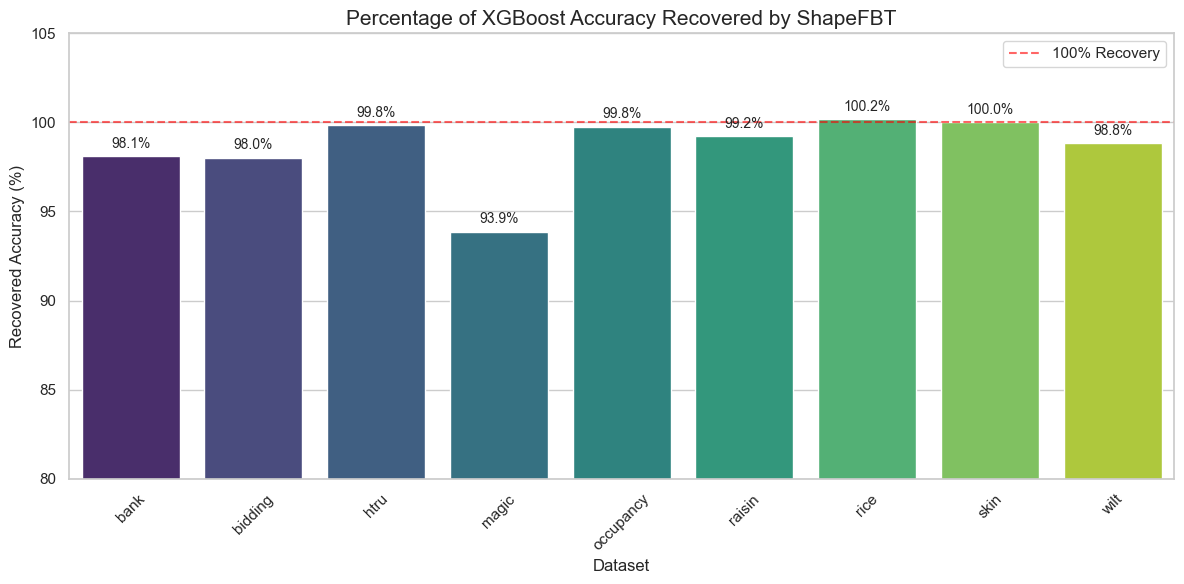

In [ ]:
# Cell 6: Calculate and Plot Recovered Accuracy
# We define "Recovered Accuracy" as ShapeFBT_Test_Acc / XGBoost_Test_Acc

# 1. Prepare the data
xgb_best = best_per_dataset[best_per_dataset['model'] == 'XGBoost'][['dataset', 'test_acc']].rename(columns={'test_acc': 'xgb_acc'})
shape_best = best_per_dataset[best_per_dataset['model'] == 'ShapeFBT'][['dataset', 'test_acc']].rename(columns={'test_acc': 'shape_acc'})

# Merge and calculate ratio
recovered_df = pd.merge(xgb_best, shape_best, on='dataset').dropna()
recovered_df['recovered_accuracy'] = (recovered_df['shape_acc'] / recovered_df['xgb_acc']) * 100

# 2. Plotting
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=recovered_df, x='dataset', y='recovered_accuracy', palette='viridis')

# Add a reference line at 100% (Full Recovery)
plt.axhline(100, ls='--', color='red', alpha=0.6, label='100% Recovery')

# Annotate bars with the percentage value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10)

plt.title('Percentage of XGBoost Accuracy Recovered by ShapeFBT', fontsize=15)
plt.ylabel('Recovered Accuracy (%)')
plt.xlabel('Dataset')
plt.ylim(80, 105) # Focused on the 80-100% range
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Cell 7: Depth-wise averages for SagiFBT, ShapeFBT, ShapeCART/SGT

# Keep only the requested model families
models_depth = ['FBT', 'ShapeFBT', 'ShapeCART', 'CART']
depth_df = results_hp[results_hp['model'].isin(models_depth)].copy()

# Parse depth per model, with fallback to hyperparameters when max_depth is empty
def _extract_depth(row):
    hp_raw = row.get('hyperparameters', np.nan)
    hp = {}
    if pd.notna(hp_raw):
        try:
            hp = json.loads(hp_raw)
        except Exception:
            hp = {}

    model = row['model']
    max_depth_col = row.get('max_depth', np.nan)

    if model == 'ShapeFBT':
        return hp.get('outer_tree_max_depth', max_depth_col)

    # FBT and ShapeCART: prefer max_depth column, then fallback to hp['max_depth']
    if pd.notna(max_depth_col) and str(max_depth_col).strip() != '':
        return max_depth_col
    return hp.get('max_depth', np.nan)


depth_df['depth_used'] = depth_df.apply(_extract_depth, axis=1)
depth_df['depth_used'] = pd.to_numeric(depth_df['depth_used'], errors='coerce')

# Generalization gap per row
depth_df['generalization_gap'] = depth_df['train_acc'] - depth_df['test_acc']

# Rename FBT to SagiFBT for display
depth_df['model_display'] = depth_df['model'].replace({'FBT': 'SagiFBT', 'ShapeCART': 'ShapeCART (SGT)'})

# Quick sanity check: number of unique depths found for each model
depth_coverage = (
    depth_df.dropna(subset=['depth_used'])
    .groupby('model_display')['depth_used']
    .nunique()
    .sort_values(ascending=False)
)
print('Unique depth count per model:')
print(depth_coverage)

# Average over all other hyperparameters/folds/seeds/datasets at each depth
avg_by_depth = (
    depth_df.dropna(subset=['depth_used'])
    .groupby(['model_display', 'depth_used'], as_index=False)
    .agg(
        test_acc_mean=('test_acc', 'mean'),
        test_acc_std=('test_acc', 'std'),
        generalization_gap_mean=('generalization_gap', 'mean'),
        generalization_gap_std=('generalization_gap', 'std'),
        n_trials=('test_acc', 'size')
    )
    .sort_values(['model_display', 'depth_used'])
)

avg_by_depth.head(20)

Unique depth count per model:
model_display
CART               5
SagiFBT            5
ShapeCART (SGT)    5
ShapeFBT           5
Name: depth_used, dtype: int64


,model_display,depth_used,test_acc_mean,test_acc_std,generalization_gap_mean,generalization_gap_std,n_trials
0,CART,2.0,0.911218,0.075548,0.004269,0.011760,1620
1,CART,3.0,0.923024,0.068632,0.004709,0.011065,1890
2,CART,4.0,0.928107,0.064534,0.005279,0.010977,1935
3,CART,5.0,0.931515,0.065015,0.005474,0.012091,1935
4,CART,6.0,0.932569,0.063858,0.006934,0.013447,1620
5,SagiFBT,2.0,0.889957,0.108908,0.004605,0.012866,1440
6,SagiFBT,3.0,0.897478,0.092589,0.004541,0.011901,1215
7,SagiFBT,4.0,0.907993,0.079912,0.005093,0.012608,1930
8,SagiFBT,5.0,0.907027,0.081914,0.004891,0.012597,1975
9,SagiFBT,6.0,0.912162,0.077972,0.005463,0.012455,2394


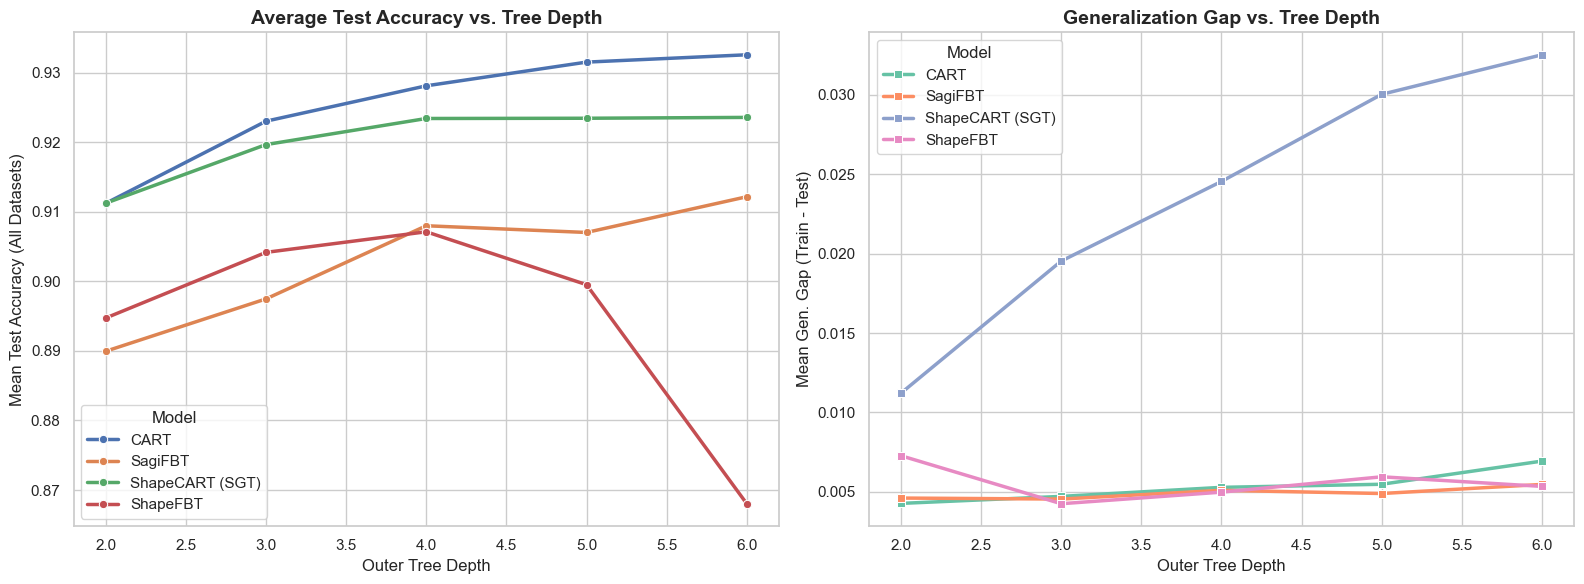

In [10]:
# Cell 8: Plot test accuracy and generalization gap vs tree depth (averaged)
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Test Accuracy vs. Depth ---
sns.lineplot(
    data=avg_by_depth, 
    x='depth_used', 
    y='test_acc_mean', 
    hue='model_display', 
    marker='o', 
    ax=ax1,
    linewidth=2.5
)
ax1.set_title('Average Test Accuracy vs. Tree Depth', fontsize=14, fontweight='bold')
ax1.set_xlabel('Outer Tree Depth', fontsize=12)
ax1.set_ylabel('Mean Test Accuracy (All Datasets)', fontsize=12)
ax1.legend(title='Model')

# --- Plot 2: Generalization Gap vs. Depth ---
sns.lineplot(
    data=avg_by_depth, 
    x='depth_used', 
    y='generalization_gap_mean', 
    hue='model_display', 
    marker='s', 
    ax=ax2,
    linewidth=2.5,
    palette='Set2'
)
ax2.set_title('Generalization Gap vs. Tree Depth', fontsize=14, fontweight='bold')
ax2.set_xlabel('Outer Tree Depth', fontsize=12)
ax2.set_ylabel('Mean Gen. Gap (Train - Test)', fontsize=12)
ax2.legend(title='Model')

plt.tight_layout()
plt.show()

In [1]:
# Pivot to see how many trials we have per depth/model
sample_size_pivot = avg_by_depth.pivot(
    index='depth_used', 
    columns='model_display', 
    values='n_trials'
).fillna(0).astype(int)

print("Number of individual runs (folds/seeds) contributing to each data point:")
display(sample_size_pivot)

NameError: name 'avg_by_depth' is not defined

In [ ]:
# Cell 10: Per-dataset depth-wise averages

# 1. Filter models and extract depth (keep your existing logic)
models_depth = ['FBT', 'ShapeFBT', 'ShapeCART', 'CART']
depth_df = results_hp[results_hp['model'].isin(models_depth)].copy()

depth_df['depth_used'] = depth_df.apply(_extract_depth, axis=1)
depth_df['depth_used'] = pd.to_numeric(depth_df['depth_used'], errors='coerce')
depth_df['generalization_gap'] = depth_df['train_acc'] - depth_df['test_acc']
depth_df['model_display'] = depth_df['model'].replace({'FBT': 'SagiFBT', 'ShapeCART': 'ShapeCART (SGT)'})

# 2. AGGREGATION CHANGE: Include 'dataset' in the groupby
avg_by_depth_dataset = (
    depth_df.dropna(subset=['depth_used'])
    .groupby(['dataset', 'model_display', 'depth_used'], as_index=False)
    .agg(
        test_acc_mean=('test_acc', 'mean'),
        test_acc_std=('test_acc', 'std'),
        generalization_gap_mean=('generalization_gap', 'mean'),
        n_trials=('test_acc', 'size')
    )
    .sort_values(['dataset', 'model_display', 'depth_used'])
)

print(f"Aggregation complete. Calculated means for {avg_by_depth_dataset['dataset'].nunique()} datasets.")
avg_by_depth_dataset.head()

Aggregation complete. Calculated means for 9 datasets.


,dataset,model_display,depth_used,test_acc_mean,test_acc_std,generalization_gap_mean,n_trials
0,bank,CART,2.0,0.890485,0.015775,0.013826,180
1,bank,CART,3.0,0.927636,0.022443,0.015374,210
2,bank,CART,4.0,0.940195,0.022326,0.016928,215
3,bank,CART,5.0,0.954926,0.024592,0.012002,215
4,bank,CART,6.0,0.956323,0.026435,0.011090,180


In [3]:
# Cell 11: Faceted Visualization (Test Accuracy per Dataset)

# Use relplot to create a grid of line plots
g = sns.relplot(
    data=avg_by_depth_dataset,
    x="depth_used",
    y="test_acc_mean",
    hue="model_display",
    col="dataset",
    col_wrap=3,      # Show 3 datasets per row
    kind="line",
    marker="o",
    height=4,
    aspect=1.2,
    facet_kws={'sharey': False} # Set to True if you want a uniform Y-axis
)

# Customizing the appearance
g.set_axis_labels("Tree Depth", "Mean Test Accuracy")
g.set_titles("{col_name}") # Titles will be the dataset names
g.fig.suptitle("Test Accuracy vs. Tree Depth (Per Dataset)", fontsize=16, fontweight='bold', y=1.02)

plt.show()

NameError: name 'sns' is not defined